In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import shutil
import os

DRIVE_DIR = "/content/drive/MyDrive/PI_II"
ZIP_NAME = "DATASET.zip"
WORK_DIR = "/content/work"

os.makedirs(WORK_DIR, exist_ok=True)

shutil.copy(
    os.path.join(DRIVE_DIR, ZIP_NAME),
    os.path.join(WORK_DIR, ZIP_NAME)
)

print("Dataset ZIP copiado a la instancia")


Dataset ZIP copiado a la instancia


In [3]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/{ZIP_NAME}", 'r') as zip_ref:
    zip_ref.extractall(WORK_DIR)

print("Dataset descomprimido")


Dataset descomprimido


In [5]:
import os
import pandas as pd

# Ruta base
dataset_path = WORK_DIR

# Extensiones válidas
image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
txt_exts = ('.txt',)

summary = []

for root, dirs, files in os.walk(dataset_path):

    image_count = sum(
        1 for f in files
        if f.lower().endswith(image_exts)
    )

    txt_count = sum(
        1 for f in files
        if f.lower().endswith(txt_exts)
    )

    total_count = image_count + txt_count

    # Solo mostrar carpetas que tengan archivos
    if total_count > 0:
        summary.append({
            "Carpeta": root.replace(dataset_path, ""),
            "Imágenes": image_count,
            "TXT": txt_count,
            "Total": total_count
        })

# Crear DataFrame
df = pd.DataFrame(summary)

# Ordenar
df = df.sort_values("Carpeta").reset_index(drop=True)

# Mostrar tabla
display(df)

# Totales generales
print("\nRESUMEN GENERAL")
print(f"Total imágenes: {df['Imágenes'].sum()}")
print(f"Total TXT: {df['TXT'].sum()}")
print(f"Total archivos: {df['Total'].sum()}")

,Carpeta,Imágenes,TXT,Total
0,/DATASET/train/images,713,0,713
1,/DATASET/train/labels,0,713,713
2,/DATASET/val/images,108,0,108
3,/DATASET/val/labels,0,108,108



RESUMEN GENERAL
Total imágenes: 821
Total TXT: 821
Total archivos: 1642


In [6]:
!pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.6 MB/s eta 0:00:00


In [7]:
import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA: True
GPU: NVIDIA A100-SXM4-40GB


In [8]:
import yaml

DATA_YAML_PATH = "/content/work/DATASET/data.yaml"

with open(DATA_YAML_PATH, "r") as f:
    data = yaml.safe_load(f)

data["path"] = "/content/work/DATASET"

with open(DATA_YAML_PATH, "w") as f:
    yaml.dump(data, f)

print("data.yaml corregido con ruta absoluta")


data.yaml corregido con ruta absoluta


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/work/DATASET/data.yaml",
    epochs=100,
    imgsz=640,
    batch=32,
    device=0,
    workers=8,
    name="Ch_parts_v2",

    mosaic=0.0,
    mixup=0.0,

    patience=40,

    lr0=0.001,

    cache="disk",

    plots=True
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/work/DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=Ch_parts_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b0f9016b170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


===== results.png =====


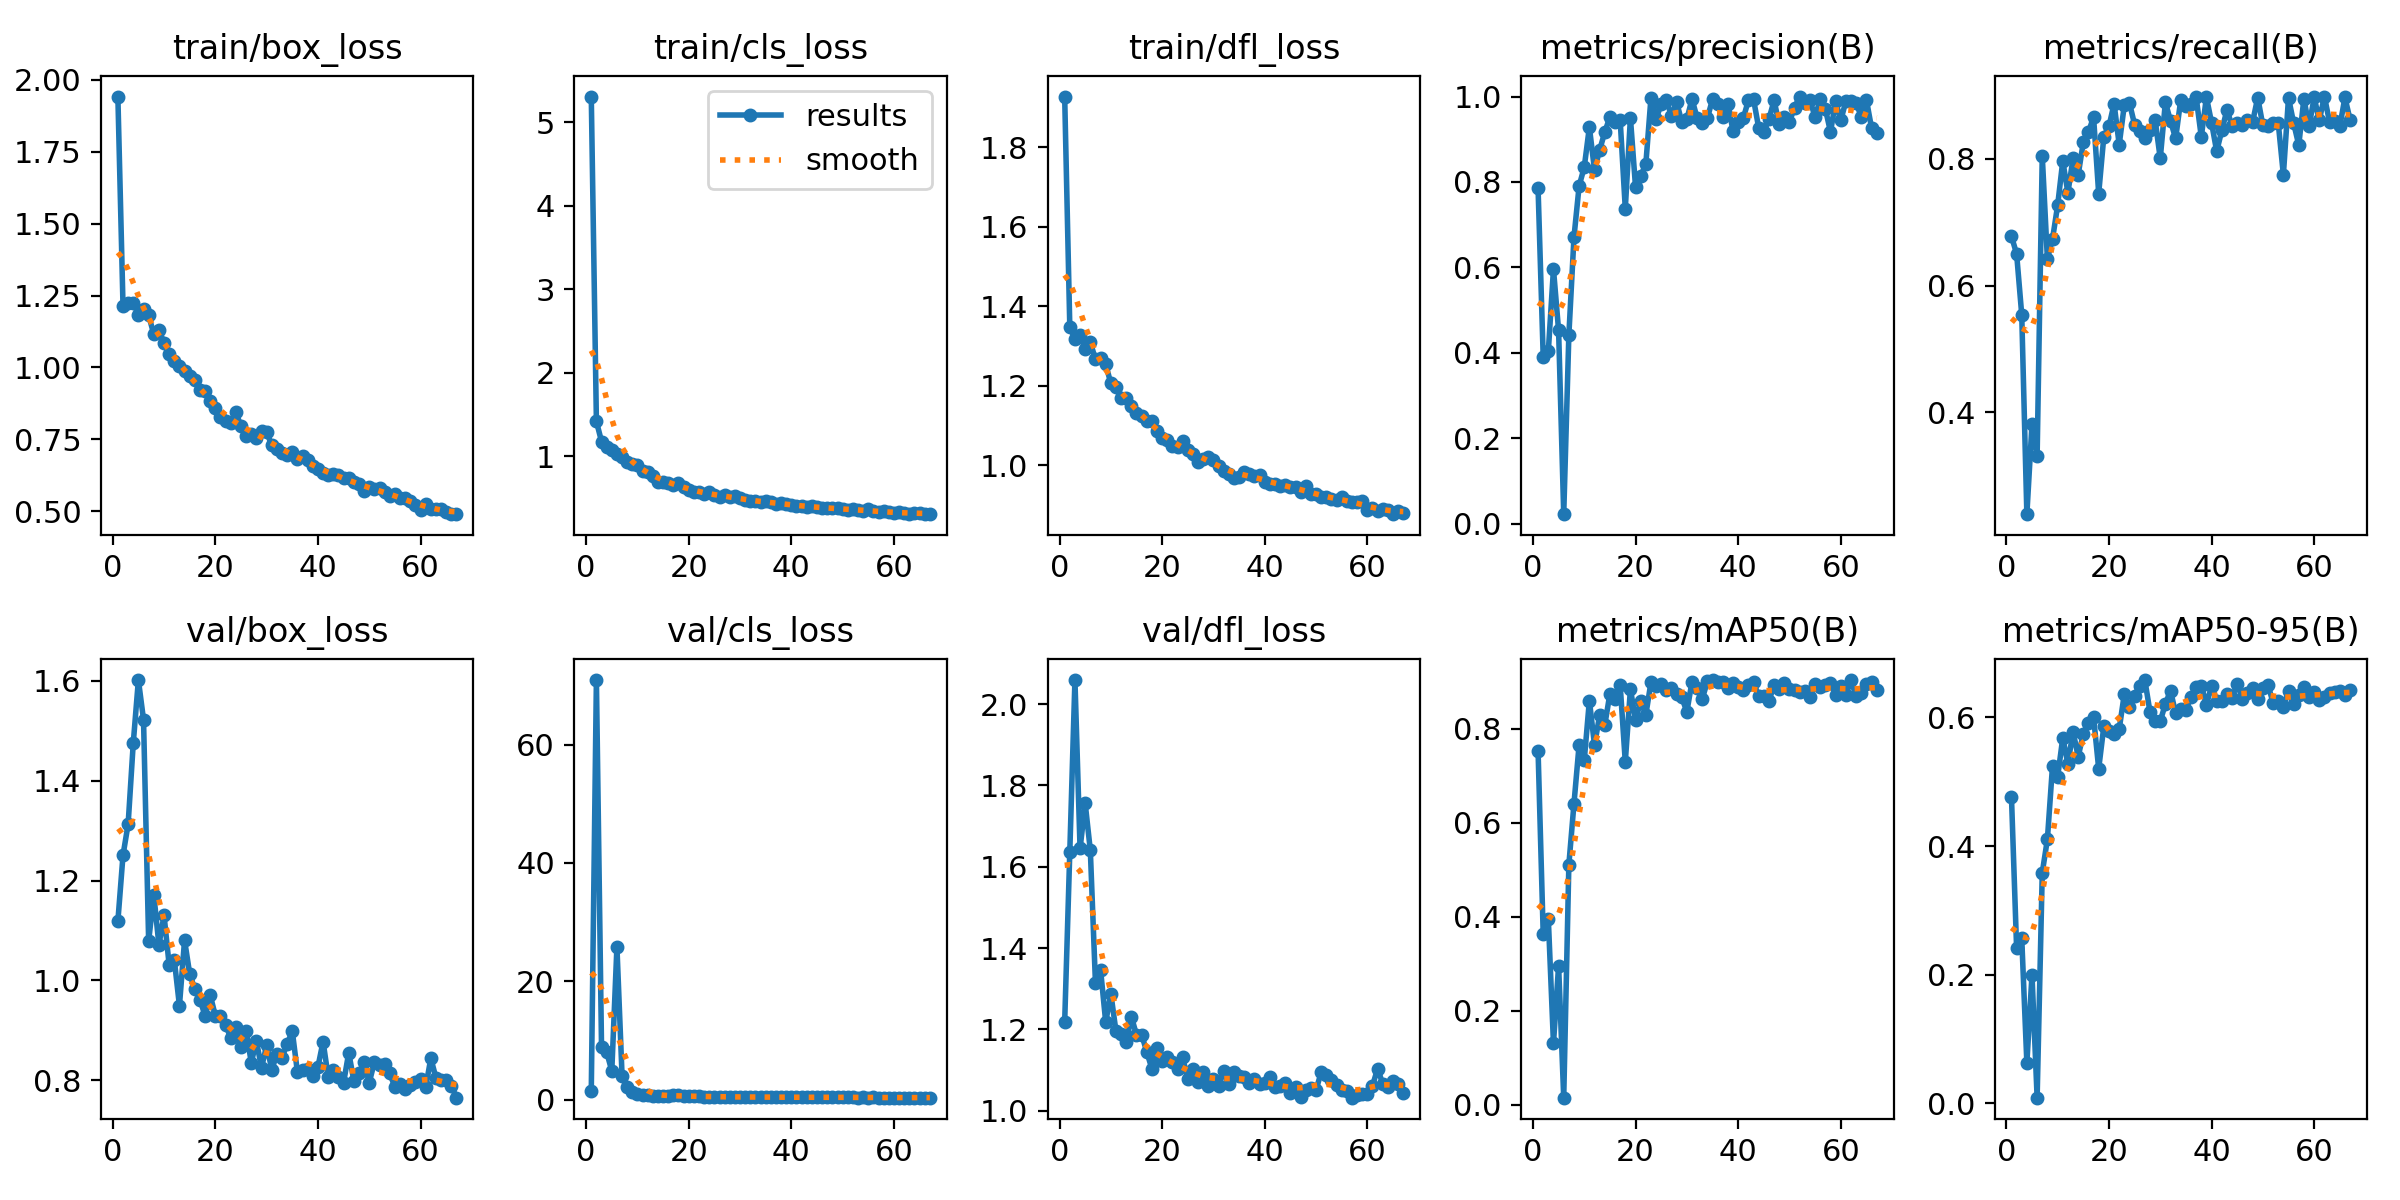


===== confusion_matrix.png =====


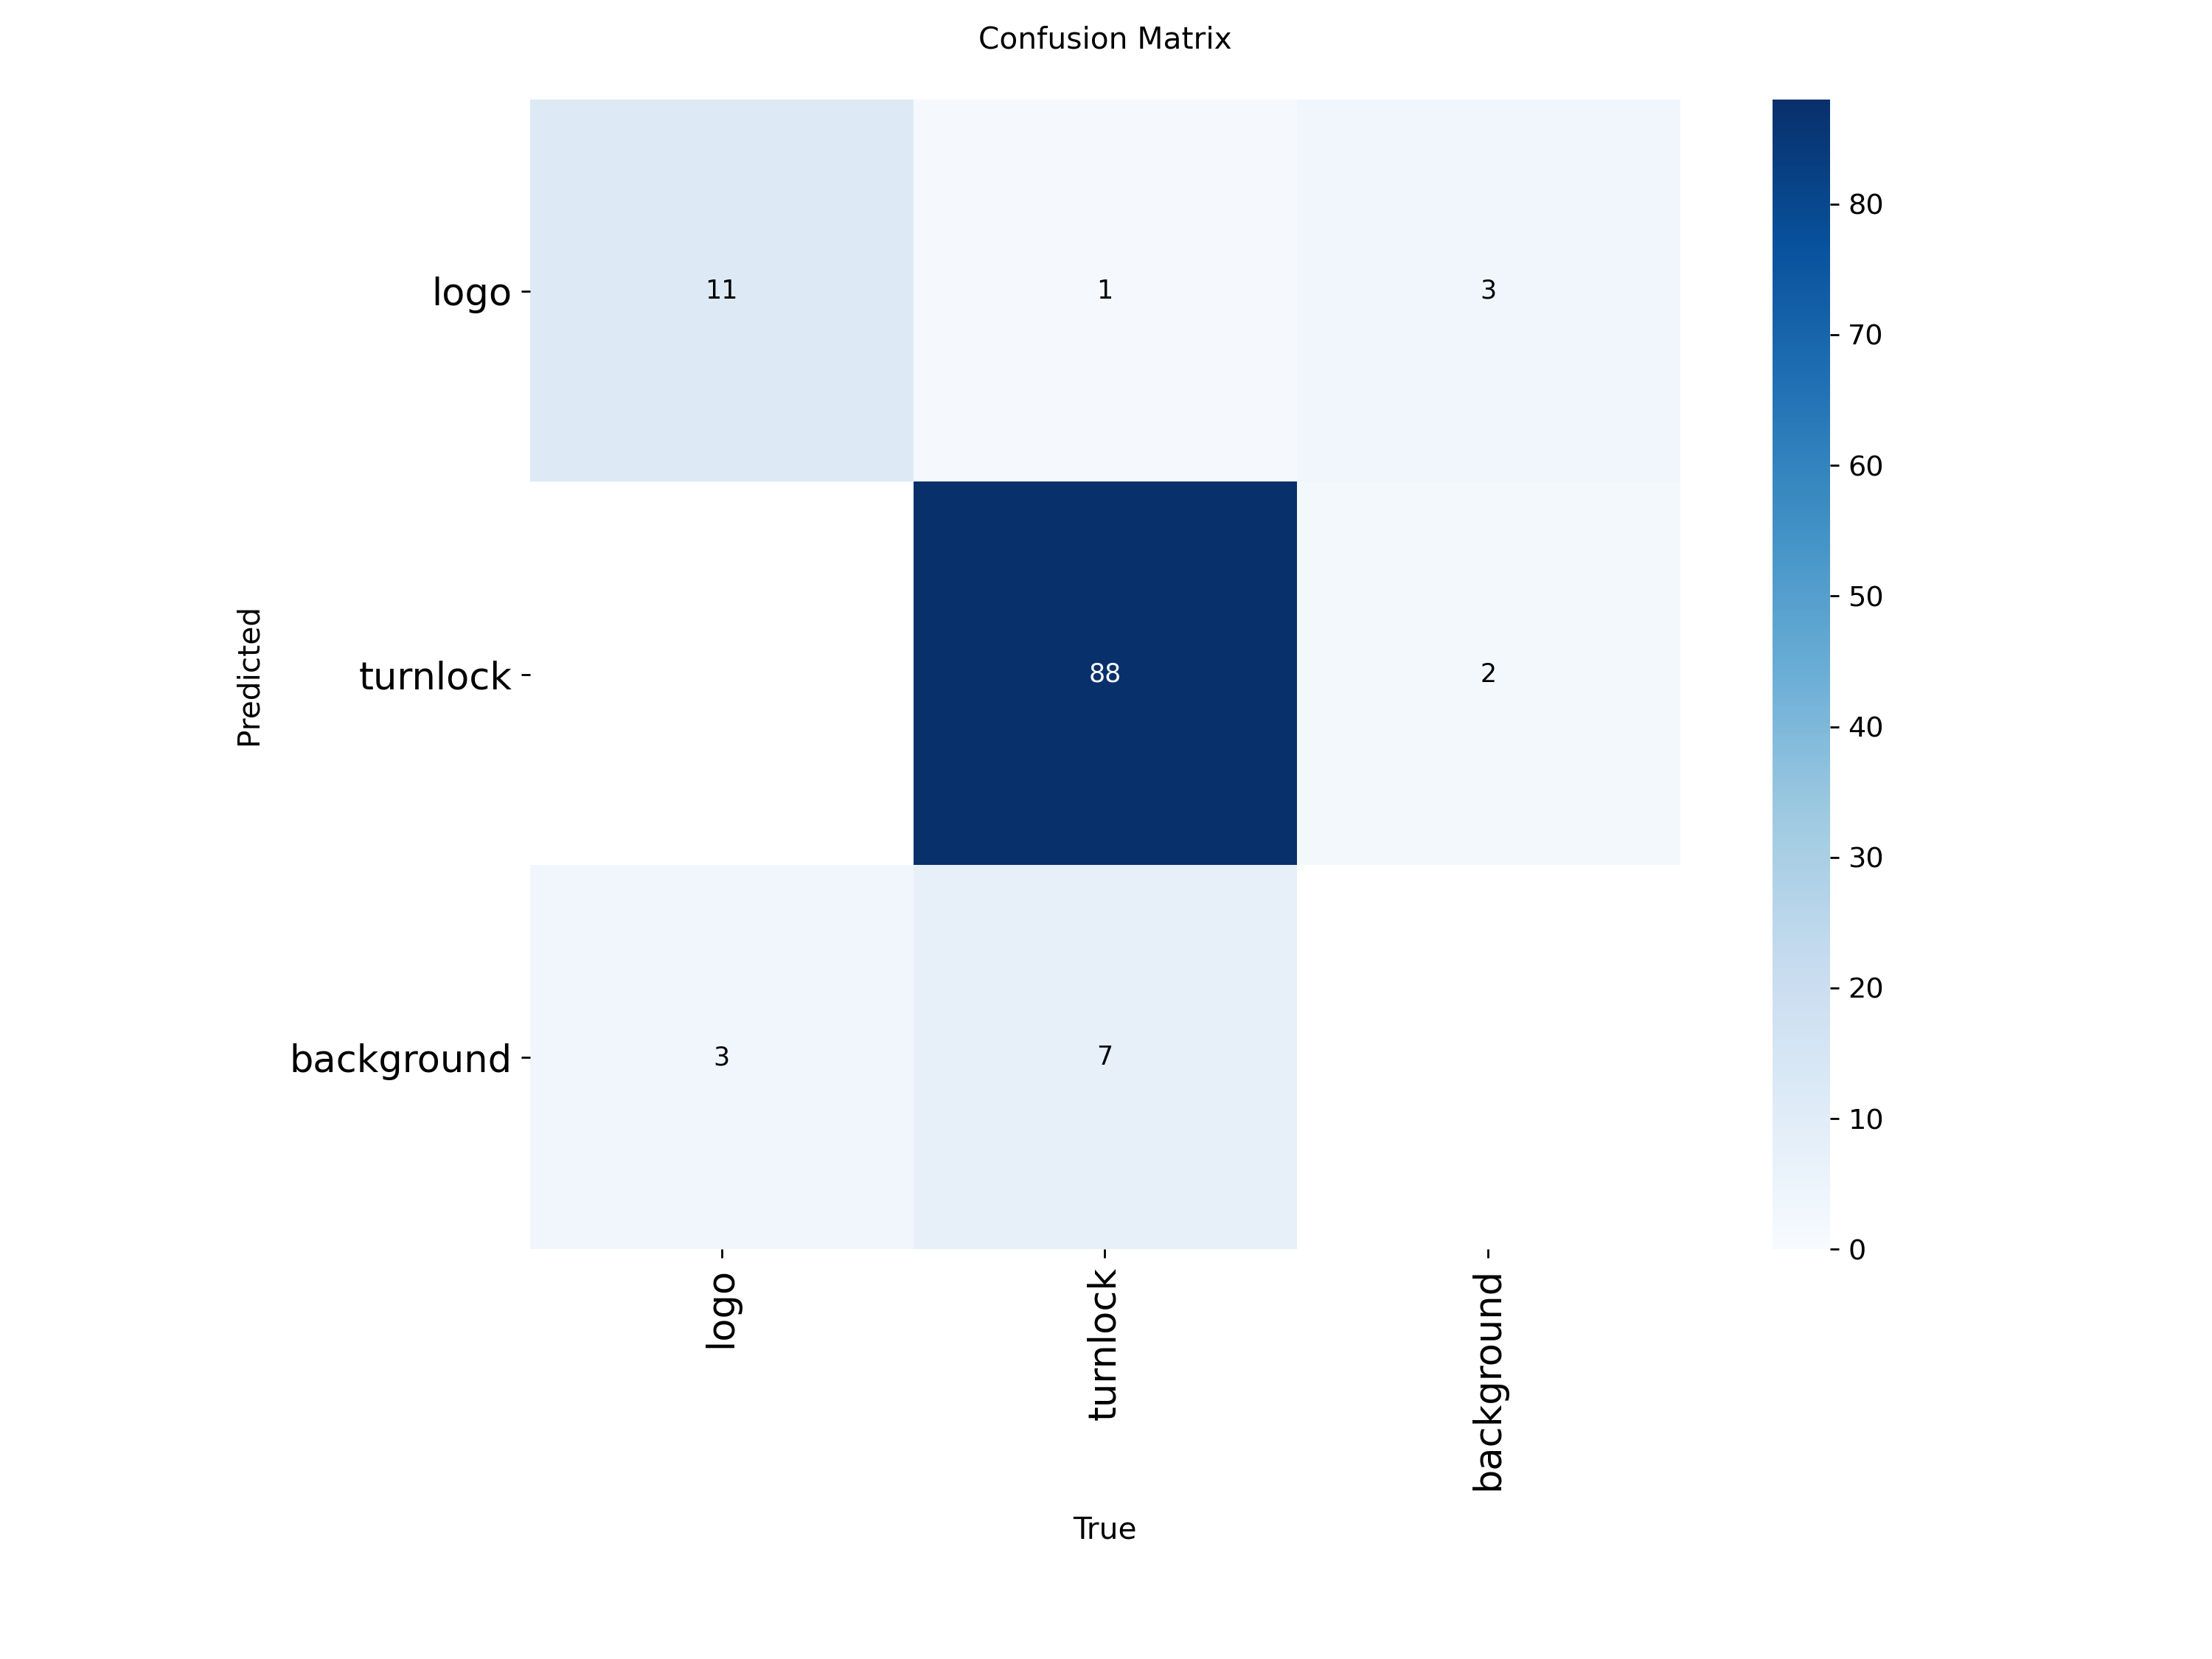

In [18]:
from IPython.display import Image, display
import os

RUN_PATH = "/content/runs/detect/Ch_parts_v2"

files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png"
]

for f in files:
    path = os.path.join(RUN_PATH, f)
    if os.path.exists(path):
        print(f"\n===== {f} =====")
        display(Image(filename=path, width=800))

In [20]:
import os
import shutil

BASE_DRIVE = "/content/drive/MyDrive/PI_II"
RUN_DIR = "runs/detect/Ch_parts_v2"

os.makedirs(BASE_DRIVE, exist_ok=True)

# verificar que exista el entrenamiento
assert os.path.exists(RUN_DIR), "❌ No existe la carpeta de entrenamiento"

# copiar TODA la carpeta (mejor práctica)
DEST = os.path.join(BASE_DRIVE, "Ch_parts_v2")

if os.path.exists(DEST):
    shutil.rmtree(DEST)

shutil.copytree(RUN_DIR, DEST)

print("✅ Todo el entrenamiento copiado a Drive")


✅ Todo el entrenamiento copiado a Drive


In [28]:
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
import uuid
import cv2

MODEL_PATH = "/content/runs/detect/Ch_parts_v2/weights/best.pt"

UPLOAD_DIR = "/content/test_upload"
CROP_DIR = "/content/test_crops"

os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(CROP_DIR, exist_ok=True)

model = YOLO(MODEL_PATH)

uploader = widgets.FileUpload(
    accept=".jpg,.jpeg,.png",
    multiple=False
)

btn_process = widgets.Button(
    description="Agregar detección + recortes",
    button_style="success"
)

out2 = widgets.Output()

def process_uploaded_image_append_side(b):

    with out2:

        if len(uploader.value) == 0:
            print("Primero selecciona una imagen.")
            return

        run_id = str(uuid.uuid4())[:8]

        upload_dir_run = f"{UPLOAD_DIR}/{run_id}"
        crop_dir_run = f"{CROP_DIR}/{run_id}"

        os.makedirs(upload_dir_run, exist_ok=True)
        os.makedirs(crop_dir_run, exist_ok=True)

        item = list(uploader.value.values())[0]

        filename = item["metadata"]["name"]
        content = item["content"]

        uploaded_image_path = os.path.join(upload_dir_run, filename)

        with open(uploaded_image_path, "wb") as f:
            f.write(content)

        results = model.predict(
            source=uploaded_image_path,
            conf=0.25,
            save=False,
            verbose=False
        )

        result = results[0]

        img = Image.open(uploaded_image_path).convert("RGB")

        plotted = result.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        boxes = result.boxes

        crops = []

        if boxes is not None and len(boxes) > 0:

            for i, box in enumerate(boxes):

                cls_id = int(box.cls[0])
                conf = float(box.conf[0])

                class_name = model.names[cls_id]

                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

                crop = img.crop((x1, y1, x2, y2))

                crop_name = f"{i+1}_{class_name}_{conf:.2f}.jpg"

                crop_path = os.path.join(crop_dir_run, crop_name)

                crop.save(crop_path)

                crops.append((crop, crop_name))

        print("=" * 80)
        print("Imagen procesada:", filename)

        total_cols = 1 + max(1, len(crops))

        plt.figure(figsize=(5 * total_cols, 5))

        plt.subplot(1, total_cols, 1)
        plt.imshow(plotted)
        plt.axis("off")
        plt.title("Detección")

        if len(crops) == 0:

            plt.subplot(1, total_cols, 2)
            plt.text(0.5, 0.5, "Sin recortes", ha="center", va="center")
            plt.axis("off")

        else:

            for idx, (crop, crop_name) in enumerate(crops, start=2):

                plt.subplot(1, total_cols, idx)
                plt.imshow(crop)
                plt.axis("off")
                plt.title(crop_name)

        plt.tight_layout()
        plt.show()

        print("Recortes guardados en:", crop_dir_run)

btn_process.on_click(process_uploaded_image_append_side)

display(uploader)
display(btn_process)
display(out2)

FileUpload(value={}, accept='.jpg,.jpeg,.png', description='Upload')

Button(button_style='success', description='Agregar detección + recortes', style=ButtonStyle())

Output()